In [1]:
!pip install -q transformers accelerate bitsandbytes datasets scikit-learn torch huggingface_hub

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 20.4 MB/s eta 0:00:00


In [2]:
import torch
import numpy as np
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, BertForMaskedLM
from sklearn.metrics import f1_score, classification_report
from tqdm import tqdm
from huggingface_hub import login
from google.colab import userdata
import pandas as pd


hf_token = userdata.get('hf_token')
login(token=hf_token)

# Aplicamos el modelo en GPU
if torch.cuda.is_available():
    device = torch.device("cuda")
    print("Usando GPU CUDA (Google Colab)")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Usando GPU MPS (Mac Pro M5)")
else:
    device = torch.device("cpu")
    print("Usando CPU")

# Cargamos el conjunto de datos FinTextSen
print("\nCargando FinTextSen.csv...")
dataset = pd.read_csv('FinTextSen_clean.csv')

# Limpieza minima para evitar fallos con textos vacios o etiquetas no numericas
dataset = dataset.dropna(subset=['sentences', 'labels']).copy()
dataset['sentences'] = dataset['sentences'].astype(str).str.strip()
dataset = dataset[dataset['sentences'] != ''].copy()
dataset['labels'] = dataset['labels'].astype(int)
print(f"Filas validas para inferencia: {len(dataset)}")


# Mapeo de etiquetas
label_map = {0: "negative", 1: "neutral", 2: "positive"}
inverse_label_map = {"negative": 0, "neutral": 1, "positive": 2}

Usando GPU CUDA (Google Colab)

Cargando FinTextSen.csv...
Filas validas para inferencia: 1680


In [3]:
# Evaluacion de FinBERT
print("\n--- Evaluando ProsusAI/finbert ---")
finbert_name = "ProsusAI/finbert"
finbert_tokenizer = AutoTokenizer.from_pretrained(finbert_name)
finbert_model = AutoModelForSequenceClassification.from_pretrained(finbert_name).to(device)
finbert_model.eval()

finbert_preds = []
true_labels = []

# Ajustamos muestras de ProsusAI/finbert mapea las salidas como: 0: positive, 1: negative, 2: neutral.
finbert_output_map = {0: 2, 1: 0, 2: 1}

with torch.no_grad():
    for idx, row in tqdm(dataset.iterrows(), desc="FinBERT Inference", total=len(dataset)):
        inputs = finbert_tokenizer(row['sentences'], return_tensors="pt", truncation=True, max_length=512).to(device)
        outputs = finbert_model(**inputs)
        pred_idx = torch.argmax(outputs.logits, dim=1).item()

        finbert_preds.append(finbert_output_map[pred_idx])
        true_labels.append(row['labels'])

print("\nResultados FinBERT:")
print("Micro F1:", f1_score(true_labels, finbert_preds, average='micro'))
print("Macro F1:", f1_score(true_labels, finbert_preds, average='macro'))


--- Evaluando ProsusAI/finbert ---


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/758 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/252 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]


FinBERT Inference: 100%|██████████| 1680/1680 [00:17<00:00, 95.50it/s] 


Resultados FinBERT:
Micro F1: 0.25595238095238093
Macro F1: 0.2723321904729003


## Matriz de confusión - FinBERT

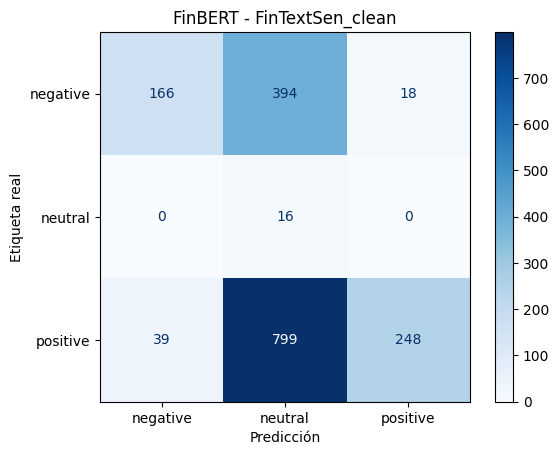

In [5]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

labels = [0, 1, 2]
display_labels = ['negative', 'neutral', 'positive']

cm = confusion_matrix(true_labels, finbert_preds, labels=labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=display_labels)

disp.plot(cmap='Blues', values_format='d')
plt.title('FinBERT - FinTextSen_clean')
plt.xlabel('Predicción')
plt.ylabel('Etiqueta real')
plt.savefig('FinBERT_confusion_matrix_finbert.png')
plt.show()
